<a href="https://colab.research.google.com/github/varsha2410ab/PEP---SUMMER/blob/main/RNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip3 install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from tqdm import tqdm

In [9]:
class SingleRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(SingleRNN, self).__init__()

        self.Wx = nn.Parameter(torch.randn(n_inputs, n_neurons))
        self.Wy = nn.Parameter(torch.randn(n_neurons, n_neurons))
        self.b = nn.Parameter(torch.zeros(1, n_neurons))

    def forward(self, X0, X1):
        Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b)
        Y1 = torch.tanh(torch.mm(Y0, self.Wy) + torch.mm(X1, self.Wx) + self.b)

        return Y0, Y1

In [13]:
N_INPUT = 4
N_NEURONS = 1

X0_batch = torch.tensor([
    [0, 1, 2, 0],
    [3, 4, 5, 0],
    [6, 7, 8, 0],
    [9, 0, 1, 0]
], dtype=torch.float)

X1_batch = torch.tensor([
    [9, 8, 7, 0],
    [0, 0, 0, 0],
    [6, 5, 4, 0],
    [3, 2, 1, 0]
], dtype=torch.float)

model = SingleRNN(N_INPUT, N_NEURONS)

Y0_val, Y1_val = model(X0_batch, X1_batch)

print(Y0_val)
print(Y1_val)

tensor([[-0.9989],
        [-1.0000],
        [-1.0000],
        [-1.0000]], grad_fn=<TanhBackward0>)
tensor([[-1.0000],
        [-0.1243],
        [-1.0000],
        [-0.9884]], grad_fn=<TanhBackward0>)


In [15]:
class BasicRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(BasicRNN, self).__init__()

        self.Wx = nn.Parameter(torch.randn(n_inputs, n_neurons))
        self.Wy = nn.Parameter(torch.randn(n_neurons, n_neurons))
        self.b = nn.Parameter(torch.zeros(1, n_neurons))

    def forward(self, X0, X1):
        Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b)
        Y1 = torch.tanh(torch.mm(X1, self.Wx) +
                        torch.mm(Y0, self.Wy) + self.b)

        return Y0, Y1

In [17]:
N_INPUT = 3
N_NEURONS = 5
X0_batch = torch.tensor([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
    [9, 0, 1]
], dtype=torch.float)
X1_batch = torch.tensor([
    [9, 8, 7],
    [0, 0, 0],
    [6, 5, 4],
    [3, 2, 1]
], dtype=torch.float)
model = BasicRNN(N_INPUT, N_NEURONS)
Y0_val, Y1_val = model(X0_batch, X1_batch)
print(Y0_val)
print(Y1_val)

tensor([[-0.8349,  0.9993, -0.9365, -0.9880,  0.9999],
        [-0.9999,  1.0000, -0.9990, -1.0000,  1.0000],
        [-1.0000,  1.0000, -1.0000, -1.0000,  1.0000],
        [-0.8984, -1.0000, -1.0000, -1.0000, -1.0000]],
       grad_fn=<TanhBackward0>)
tensor([[-1.0000,  1.0000, -0.9992, -1.0000,  1.0000],
        [-0.9331,  0.3874,  0.4666, -0.9980, -0.2985],
        [-1.0000,  0.9989, -0.9587, -1.0000,  0.9982],
        [-1.0000, -0.5132, -0.9942, -0.9840,  0.2074]],
       grad_fn=<TanhBackward0>)


In [22]:
rnn = nn.RNN(3, 5)

X_batch = torch.tensor([
    [
        [0, 1, 2],
        [3, 4, 5],
        [6, 7, 8],
        [9, 0, 1]
    ],
    [
        [9, 8, 7],
        [0, 0, 0],
        [6, 5, 4],
        [3, 2, 1]
    ]
], dtype=torch.float)

hx = torch.randn(1, 5)

output = []

for i in range(2):
    out, hx = rnn(X_batch[i], hx)
    output.append(out)

print(output)

[tensor([[ 0.1987,  0.8342, -0.4290,  0.8927, -0.1491],
        [ 0.6751,  0.9949,  0.4626,  0.9994, -0.5543],
        [ 0.8587,  0.9999,  0.8419,  1.0000, -0.8778],
        [-0.8573, -0.4938,  0.4607,  0.9993, -0.9997]],
       grad_fn=<SqueezeBackward1>), tensor([[ 0.6677,  0.9999,  0.5260,  1.0000, -0.9970],
        [-0.4840,  0.1726, -0.4453,  0.4501, -0.6298],
        [ 0.6680,  0.9876, -0.0089,  1.0000, -0.9643],
        [-0.0321,  0.6939, -0.5961,  0.9877, -0.8951]],
       grad_fn=<SqueezeBackward1>)]


In [23]:
import torchvision
import torchvision.transforms as transforms

In [26]:
BATCH_SIZE = 64
transform = transforms.Compose(
    [transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=0)
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=0)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 355kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.56MB/s]


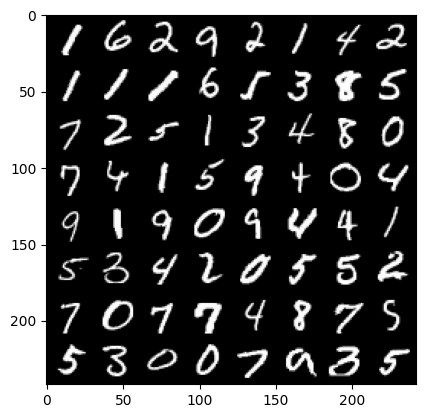

In [27]:
import matplotlib.pyplot as plt
import numpy as np
# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
# get some random training images
data_iter = iter(trainloader)
images, labels = next(data_iter)
# show images
imshow(torchvision.utils.make_grid(images))

In [34]:
N_STEPS = 28
N_INPUTS = 28
N_NEURONS = 150
N_OUTPUTS = 10
N_EPOCHS = 10

In [35]:
import torch
import torch.nn as nn

class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()

        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_neurons = n_neurons
        self.n_outputs = n_outputs

        self.rnn = nn.RNN(
            input_size=n_inputs,
            hidden_size=n_neurons,
            batch_first=True
        )

        self.fc = nn.Linear(n_neurons, n_outputs)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.n_neurons).to(x.device)

        out, hidden = self.rnn(x, h0)

        out = self.fc(hidden.squeeze(0))

        return out

In [36]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Create model
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)

# Reshape images
images = images.view(-1, 28, 28)

# Forward pass
logits = model(images)

print(logits[:10])

tensor([[ 0.0774,  0.1030, -0.1214, -0.0682, -0.0518, -0.0609, -0.0058, -0.0486,
          0.0307,  0.0902],
        [ 0.0811,  0.0969, -0.1273, -0.0695, -0.0484, -0.0553,  0.0005, -0.0545,
          0.0270,  0.0938],
        [ 0.0607,  0.0604, -0.1218, -0.0464, -0.0408, -0.0253,  0.0118, -0.0544,
          0.0112,  0.0972],
        [ 0.0754,  0.1040, -0.1132, -0.0859, -0.0509, -0.0544, -0.0006, -0.0600,
          0.0209,  0.0858],
        [ 0.0764,  0.1005, -0.1281, -0.0686, -0.0425, -0.0594, -0.0015, -0.0475,
          0.0227,  0.0958],
        [ 0.0744,  0.1030, -0.1251, -0.0713, -0.0460, -0.0611, -0.0003, -0.0460,
          0.0240,  0.0907],
        [ 0.0449,  0.0462, -0.1350, -0.0728, -0.0366, -0.0563,  0.0032, -0.0431,
          0.0036,  0.1107],
        [ 0.0712,  0.0926, -0.1235, -0.0615, -0.0408, -0.0548, -0.0028, -0.0481,
          0.0242,  0.0999],
        [ 0.0713,  0.0910, -0.1243, -0.0603, -0.0416, -0.0559, -0.0037, -0.0490,
          0.0211,  0.1012],
        [ 0.0724,  

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Accuracy function
def get_accuracy(logit, target):
    pred = torch.argmax(logit, dim=1)
    correct = (pred == target).sum().item()
    return 100 * correct / target.size(0)

In [38]:
for epoch in range(N_EPHOCS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        # reset hidden states
        model.hidden = model.init_hidden()
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)
        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH_SIZE)
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch [1/10] Loss: 0.7138 Accuracy: 76.91%
Epoch [2/10] Loss: 0.3148 Accuracy: 90.82%
Epoch [3/10] Loss: 0.2363 Accuracy: 93.21%
Epoch [4/10] Loss: 0.2039 Accuracy: 94.20%
Epoch [5/10] Loss: 0.1711 Accuracy: 95.11%
Epoch [6/10] Loss: 0.1547 Accuracy: 95.67%
Epoch [7/10] Loss: 0.1422 Accuracy: 96.00%
Epoch [8/10] Loss: 0.1293 Accuracy: 96.30%
Epoch [9/10] Loss: 0.1189 Accuracy: 96.68%
Epoch [10/10] Loss: 0.1229 Accuracy: 96.54%


In [41]:
model.eval()

test_acc = 0.0

with torch.no_grad():
    for i, (inputs, labels) in enumerate(testloader):

        inputs = inputs.view(-1, 28, 28).to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        test_acc += get_accuracy(outputs, labels)

print("Test Accuracy: {:.2f}%".format(test_acc / len(testloader)))

Test Accuracy: 96.54%


RNN TENSORFLOW IMPLEMENTATION

In [42]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

Initialized Sample Data In The Form Of Sentence

In [43]:
text = "This is a Sample Text"
chars = sorted(list(set(text)))
char_to_int = dict((c, i) for i, c in enumerate(chars))
int_to_char = dict((i, c) for i, c in enumerate(chars))

In [44]:
seq_length = 3
sequences = []
labels = []
for i in range(0, len(text) - seq_length):
    seq = text[i:i + seq_length]
    label = text[i + seq_length]
    sequences.append([char_to_int[char] for char in seq])
    labels.append(char_to_int[label])

X = np.array(sequences)
y = np.array(labels)

In [45]:
X.shape, y.shape

((18, 3), (18,))

In [46]:
X_one_hot = tf.one_hot(X, len(chars))
y_one_hot = tf.one_hot(y, len(chars))

In [48]:
model = Sequential()
model.add(SimpleRNN(50, input_shape=(seq_length, len(chars))))
model.add(Dense(len(chars), activation='softmax'))


In [50]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_one_hot, y_one_hot, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.5924
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1111 - loss: 2.5537
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1111 - loss: 2.5153
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1667 - loss: 2.4771
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1667 - loss: 2.4392
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1667 - loss: 2.4016
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1667 - loss: 2.3642
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2222 - loss: 2.3270
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2778 - loss: 2.2900
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3333 - loss: 2.2532
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3889 - loss: 2.2166
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4444 - 

In [53]:
text = "This is a sample text. This is not a simple text to be predicted"
chars = sorted(list(set(text)))
char_t_index = {char: i for i, char in enumerate(chars)}
index_t_char = {i: char for i, char in enumerate(chars)}
print(char_t_index)
print(index_t_char)

{' ': 0, '.': 1, 'T': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'h': 8, 'i': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'r': 15, 's': 16, 't': 17, 'x': 18}
{0: ' ', 1: '.', 2: 'T', 3: 'a', 4: 'b', 5: 'c', 6: 'd', 7: 'e', 8: 'h', 9: 'i', 10: 'l', 11: 'm', 12: 'n', 13: 'o', 14: 'p', 15: 'r', 16: 's', 17: 't', 18: 'x'}
